# Ollama y Langgraph


In [1]:
# Comando para instalar ollama
!apt-get update && apt-get install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,744 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,221 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,024 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnak

In [67]:
import subprocess
import time
# Inicia el servidor silenciando los logs en la celda
subprocess.Popen(['ollama', 'serve'], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Dale unos segundos para que se inicie correctamente
time.sleep(3)

In [68]:
#modelos
!ollama pull gemma4:e2b
!ollama pull qwen3:8b
!ollama pull llama3.2:3b

In [5]:
!pip install -q langgraph langchain-ollama langchain-core

In [6]:
# Instalamos lo necesario de langgraph
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_core.messages import SystemMessage
import operator

# Herramientas


In [7]:
# Calendario
import json, os
ARCHIVO = "calendario.json"

def _cargar():
    if not os.path.exists(ARCHIVO):
        return {"eventos": []}          # estado inicial vacío
    with open(ARCHIVO, "r", encoding="utf-8") as f:
        return json.load(f)

def _guardar(estado):
    with open(ARCHIVO, "w", encoding="utf-8") as f:
        json.dump(estado, f, indent=2, ensure_ascii=False)

@tool
def agregar_evento(titulo, fecha, hora, duracion_horas):
    """Herramienta para agregar eventos, le das un titulo, fecha, hora, duracion y te lo guarda
    en una base de datos"""
    data = _cargar()  # <-- Corregido aquí (alineado con el docstring)
    data["eventos"].append({
        "id": max((e["id"] for e in data["eventos"]), default=0) + 1,
        "titulo": titulo,
        "fecha": fecha,
        "hora": hora,
        "duracion_horas": duracion_horas
    })
    _guardar(data)
    return "Evento " + titulo +" en la fecha " + fecha + " agregado correctamente"

@tool
def listar_eventos(fecha=None):
    """Entrega evento por fecha o si no hay fecha, entrega todos los eventos guardados"""
    data = _cargar()["eventos"]  # <-- Corregido aquí

    if fecha is not None:
        data = [e for e in data if e["fecha"] == fecha]

    if not data:
        return "No hay eventos" + (f" para el {fecha}" if fecha else "")

    return "\n".join(
        f"[{e['id']}] {e['titulo']} - {e['fecha']} a las {e['hora']} ({e['duracion_horas']}h)"
        for e in data
    )

@tool
def modificar_evento(titulo, fecha, nueva_hora):
    """ Modifica la hora de un evento existente. Busca el evento por su título
    y su fecha (formato YYYY-MM-DD) y le cambia la hora a nueva_hora (formato HH:MM)."""
    data = _cargar()  # <-- Corregido aquí
    titulo_buscado = titulo.lower().strip()
    for e in data["eventos"]:
        if e["titulo"].lower().strip() == titulo_buscado and e["fecha"] == fecha:
            e["hora"] = nueva_hora
            _guardar(data)
            return f"Evento '{titulo}' actualizado a las {nueva_hora}."
    return "Evento no encontrado"

In [8]:
#Calculadora
import ast, operator

OPERADORES = {
    ast.Add: operator.add,
    ast.Sub: operator.sub,
    ast.Mult: operator.mul,
    ast.Div: operator.truediv,
    ast.Pow: operator.pow,
    ast.USub: operator.neg,
}

def _evaluar(nodo):
    # Un número literal → devuelve su valor
    if isinstance(nodo, ast.Constant):
        if isinstance(nodo.value, (int, float)):
            return nodo.value
        raise ValueError(f"Constante no permitida: {nodo.value!r}")

    # Operación binaria (a + b, a * b, ...)
    elif isinstance(nodo, ast.BinOp):
        tipo = type(nodo.op)
        if tipo not in OPERADORES:
            raise ValueError(f"Operador no permitido: {tipo.__name__}")
        return OPERADORES[tipo](_evaluar(nodo.left), _evaluar(nodo.right))

    # Operación unaria (-5, +3)
    elif isinstance(nodo, ast.UnaryOp):
        tipo = type(nodo.op)
        if tipo not in OPERADORES:
            raise ValueError(f"Operador unario no permitido: {tipo.__name__}")
        return OPERADORES[tipo](_evaluar(nodo.operand))

    # Cualquier otra cosa → se rechaza
    else:
        raise ValueError(f"Expresión no permitida: {type(nodo).__name__}")

@tool
def evaluar(expresion):
  """Herramienta calculadora, evalua la expresion que le entregues"""
  try:
        arbol = ast.parse(expresion, mode="eval")
        resultado = _evaluar(arbol.body)
        return str(resultado)
  except Exception as e:
        return "No se pudo evaluar por el siguiente motivo " + str(e)

In [9]:
# Buscador
!pip install -q ddgs
from ddgs import DDGS

@tool
def buscar(query):
    """Busca información en la web sobre un tema o concepto.
    Úsala para responder dudas conceptuales o factuales que requieran información actualizada."""
    # 1. Estructura temporal donde guardamos los resultados
    data = {"query": query, "resultados": []}

    # 2. Hacemos la búsqueda y llenamos la estructura
    try:
        with DDGS() as ddgs:
            for r in ddgs.text(query, max_results=5):
                data["resultados"].append({
                    "titulo": r["title"],
                    "url": r["href"],
                    "resumen": r.get("body", "")
                })
    except Exception as e:
        return "No se pudo realizar la búsqueda por el siguiente motivo " + str(e)

    # 3. Si no hay resultados, devolvemos un mensaje claro
    if not data["resultados"]:
        return f"No se encontraron resultados para: {query}"

    # 4. Convertimos a string legible
    return "\n\n".join(
        f"[{i}] {e['titulo']}\n{e['url']}\n{e['resumen']}"
        for i, e in enumerate(data["resultados"], start=1)
    )

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 75.7 MB/s eta 0:00:00


In [10]:
print(buscar.invoke({"query": "leyes de newton que son?"}))

[1] Comprendiendo las Leyes de Newton y su Aplicación... | Algor Cards
https://cards.algoreducation.com/es/content/enE7k4PT/leyes-newton-aplicacion-cotidiana
Las leyes de Newton son pilares en la física clásica, proporcionando una comprensión esencial de los principios que rigen las fuerzas y el movimiento. La Primera Ley de Newton, o Ley de la Inercia, establece que un objeto en reposo permanecerá en reposo...

[2] capítulo de libro de Dinámica: Problemas de Mecánica: Leyes de...
https://teachy.ai/es/libros/educacion-media/media-superior-1-grado/fisica-a-espanol/leyes-de-newton-y-fuerzas-fundamentales-e6f18
Newton desarrolló las tres leyes fundamentales que describen el movimiento de los objetos, formando la base de la mecánica clásica. Estas leyes son aplicables desde la caída de una manzana hasta el despegue de un cohete, reflejando su presencia en fenómenos cotidianos y complejos.

[3] Leyes de Newton diego luna by Diego Andres Luna Altamar on Prezi
https://prezi.com/p/ctsnbh9rr7wm

In [17]:
if __name__ == "__main__":
    print(agregar_evento("Examen de Álgebra", "2026-06-08", "09:00", 2))
    print(listar_eventos("2026-06-08"))
    #print(listar_eventos())

Evento Examen de Álgebra en la fecha 2026-06-08 agregado correctamente
[1] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[2] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[3] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[4] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[5] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[6] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[7] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)
[8] Examen de Álgebra - 2026-06-08 a las 09:00 (2h)


# Extras


In [51]:
from IPython.display import Image, display

def imprimirGrafo(app):
    try:
        display(Image(app.get_graph(xray=True).draw_mermaid_png()))
    except Exception as e:
        print(f"No se pudo imprimir el grafo: {e}")
        print("Nota: Es posible que necesites instalar las dependencias visuales.")

# Agentes y testeo



In [12]:
gemma = ChatOllama(model="gemma4:e2b")
qwen = ChatOllama(model="qwen3:8b", temperature=0)
llama = ChatOllama(model="llama3.2:3b")

In [57]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    siguiente: str
    valida: bool
    feedback: str
    intentos: int

In [24]:
agente_calculador_tools = [evaluar]
qwen_tools = qwen.bind_tools(agente_calculador_tools)

Prompt_Calculadora = """Eres un calculadora, tu mision es entregar resultados cuando utilices la herramienta para evaluar expresiones,
tienes que hacer lo siguiente:
1.- Dada una pregunta matematica tienes que volverla una expresion matematica pura, ejemplo;
 "Cuanto es 2 mas 2?"
 respuesta: 2+2.
 "Cuanto es 4 mas 4 mas cuatro todo eso dividido por 2?"
 respuesta: (4+4+4)/2.
2.- Luego mandaras esa expresion que creaste a la herramienta para que te de un resultado, tu solo devuelves el resultado numerico, no agregues nada mas.
IMPORTANTE:
 1 Para raices y potencias siempre usa **, nunca ^.
 2 Las raíces se escriben como potencia fraccionaria: "raíz cuadrada de X" → X**0.5.
 3 "X elevado a Y" → X**Y.
 4 Nunca uses símbolos como √ ni funciones como sqrt()
"""
def agente_calculador(State):
    llm = qwen_tools
    messages = State["messages"]
    system_prompt= [SystemMessage(content=Prompt_Calculadora)]
    respuesta = llm.invoke(system_prompt + messages)
    return {"messages": [respuesta]}


In [29]:
workflow = StateGraph(State)
workflow.add_node("Agente_Calculador", agente_calculador)
workflow.add_node("tools", ToolNode(agente_calculador_tools))

workflow.add_edge(START, "Agente_Calculador")
workflow.add_conditional_edges("Agente_Calculador", tools_condition)
workflow.add_edge("tools", "Agente_Calculador")

app_agenteCalculador = workflow.compile()

In [35]:
#entrada = {"messages": [("user", "¿Cuánto es cuatro mas sies, todo eso multiplicado por 25?")]}
entrada = {"messages": [("user", "¿cual es la raiz de 25?")]}
for evento in app.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Agente_Calculador': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-16T01:30:31.177773177Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7080597797, 'load_duration': 271126972, 'prompt_eval_count': 377, 'prompt_eval_duration': 345257000, 'eval_count': 218, 'eval_duration': 6388127000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019ece0d-13de-7fb0-b36e-ca806e2329a5-0', tool_calls=[{'name': 'evaluar', 'args': {'expresion': '25**0.5'}, 'id': '5cdb4fc9-6ef3-40c4-8562-a1c83d6ffa8c', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 377, 'output_tokens': 218, 'total_tokens': 595})]}}
---
{'tools': {'messages': [ToolMessage(content='5.0', name='evaluar', id='7c278e51-5cdd-4912-96de-421f68ddd3ae', tool_call_id='5cdb4fc9-6ef3-40c4-8562-a1c83d6ffa8c')]}}
---
{'Agente_Calculador': {'messages': [AIMessage(content='5.0', additional_kwargs={}, res

In [26]:
agente_organizadorTools = [agregar_evento, listar_eventos, modificar_evento]
gemma_tools = gemma.bind_tools(agente_organizadorTools)

Prompt_organizador = """ Tu mision es encargarte en organizar los eventos del usuario.
  Tienes 3 herramientas:
    1 agregar/crear un evento → agregar_evento
    2 consultar/ver si hay algo → listar_eventos
    3 cambiar/modificar uno existente → modificar_evento
  Tienes que siempre extraer el titulo del evento, la fecha, la hora y la duracion
  cuando se quiera agregar un evento.
  Si el usuario no te da una hora de duracion, colocas duracion hora en 00:00
  IMPORTANTE:
  el formato de fechas es de la siguiente forma: "10 de junio de 2026" → 2026-06-10
  y de horas "a las 3 de la tarde" → 15:00
  EJEMPLO DE LO ESPERADO:

  USUARIO: “Agrega una reunión de estudio de Física el 10 de junio de 2026 a las 15:00
  horas.”
  (el agente debe llamar a agregar evento con los parametros:
  titulo='Reunión de Física', fecha='2026-06-10', hora='15:00', duracion_horas=0:00)

  USUARIO: “¿Tengo algún evento programado para el 15 de junio de 2026?”
  (el agente debe llamar a listar_eventos con:
  fecha='2026-06-15')


  USUARIO: “Modifica mi evento ‘Clase de Historia’ del 20 de junio de 2026 para que
  comience a las 10:00.”
  (El agente debe llamar a agregar_evento con:
  titulo='Reunión de Física', fecha='2026-06-10', hora='15:00', duracion_horas=0)
  RESPONDE SIEMPRE EN ESPAÑOL
 """
def agente_organizador(State):
    llm = gemma_tools
    messages = State["messages"]
    system_prompt= [SystemMessage(content=Prompt_organizador)]
    respuesta = llm.invoke(system_prompt + messages)
    return {"messages": [respuesta]}

In [27]:
builder = StateGraph(State)
builder.add_node("Agente_Organizador",agente_organizador)
builder.add_node("tools", ToolNode(agente_organizadorTools))

builder.add_edge(START, "Agente_Organizador")
builder.add_conditional_edges("Agente_Organizador", tools_condition)
builder.add_edge("tools", "Agente_Organizador")

app_agenteOrganizador = builder.compile()

In [18]:
entrada = {"messages": [("user", "En febredo 8 del 2027 viajare a miami a ver a Javiera, nos encontraremos a las 12:00 del dia, guardardalo en el calendario")]}
for evento in app1.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Agente_Organizador': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-06-16T03:05:17.715916428Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12236930615, 'load_duration': 738967731, 'prompt_eval_count': 653, 'prompt_eval_duration': 295267000, 'eval_count': 731, 'eval_duration': 11186929000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--019ece63-c4c3-7852-ad58-e130f75855c1-0', tool_calls=[{'name': 'agregar_evento', 'args': {'duracion_horas': 0, 'fecha': '2027-02-08', 'hora': '12:00', 'titulo': 'Viaje a Miami con Javiera'}, 'id': '635e3d67-80b1-48ff-ae66-65b68cca73f6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 653, 'output_tokens': 731, 'total_tokens': 1384})]}}
---
{'tools': {'messages': [ToolMessage(content='Evento Viaje a Miami con Javiera en la fecha 2027-02-08 agregado correctamente', name='agregar_evento', id='c4410ead-ddc

In [20]:
entrada = {"messages": [("user", "listame todos mis eventos")]}
for evento in app1.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Agente_Organizador': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-06-16T03:09:13.541866583Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5427255324, 'load_duration': 854992209, 'prompt_eval_count': 629, 'prompt_eval_duration': 361175000, 'eval_count': 229, 'eval_duration': 4203787999, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--019ece67-788f-7ae3-8334-a5205e1aa967-0', tool_calls=[{'name': 'listar_eventos', 'args': {}, 'id': '42eb6d0b-2ebb-4eca-ab35-d196dc1a0063', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 629, 'output_tokens': 229, 'total_tokens': 858})]}}
---
{'tools': {'messages': [ToolMessage(content='[1] clase de anatomia con javiera - 2021-01-17 a las 15:00 (0h)\n[2] Viaje a Miami con Javiera - 2027-02-08 a las 12:00 (0h)', name='listar_eventos', id='76e40f19-37f1-4f33-96db-731757013906', tool_call_id='42eb6d0b-2ebb-

In [29]:
entrada = {"messages": [("user", "Me equivoque cambia el evento viaje a Miami con Javiera , del 8 de febrero del 2027 a las 17:00")]}
for evento in app1.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Agente_Organizador': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gemma4:e2b', 'created_at': '2026-06-16T03:25:24.73686911Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7504455103, 'load_duration': 774845222, 'prompt_eval_count': 728, 'prompt_eval_duration': 81518000, 'eval_count': 411, 'eval_duration': 6640543000, 'logprobs': None, 'model_name': 'gemma4:e2b', 'model_provider': 'ollama'}, id='lc_run--019ece76-422e-7f92-80f6-7b3b07d00278-0', tool_calls=[{'name': 'modificar_evento', 'args': {'fecha': '2027-02-08', 'nueva_hora': '17:00', 'titulo': 'viaje a Miami con Javiera'}, 'id': 'da9e510f-de2c-4d2e-be5a-70d331e75c22', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 728, 'output_tokens': 411, 'total_tokens': 1139})]}}
---
{'tools': {'messages': [ToolMessage(content="Evento 'viaje a Miami con Javiera' actualizado a las 17:00.", name='modificar_evento', id='865cd2dc-2594-4a1c-8b36-aaede1f90d2b', tool_ca

In [14]:
agente_expertools = [buscar]
expertoll_tools = qwen.bind_tools(agente_expertools)

Prompt_experto = """ Tu mision es responder las preguntas conceptuales del usuario
generales, utilizando la herramienta buscar, esta te permite buscar por internet y recibir un resumen.
IMPORTANTE:
1 SIEMPRE BUSCA PRIMERO POR INTERNET
2 LUEGO redacta una explicación con tus propias palabras, de forma clara y didáctica. NO copies
los resultados ni las URLs tal cual; sintetiza la información en una respuesta propia.
responde siempre en español
 """
def agente_experto(State):
    llm = expertoll_tools
    messages = State["messages"]
    system_prompt= [SystemMessage(content=Prompt_experto)]
    respuesta = llm.invoke(system_prompt + messages)
    return {"messages": [respuesta]}

In [30]:
expert = StateGraph(State)
expert.add_node("Agente_Experto",agente_experto)
expert.add_node("tools", ToolNode(agente_expertools))

expert.add_edge(START, "Agente_Experto")
expert.add_conditional_edges("Agente_Experto", tools_condition)
expert.add_edge("tools", "Agente_Experto")

app_agenteExperto = expert.compile()

In [16]:
entrada = {"messages": [("user", "Cuales son las fases de la luna?")]}
for evento in exp.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Agente_Experto': {'messages': [AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-16T03:53:26.739021943Z', 'done': True, 'done_reason': 'stop', 'total_duration': 136179212397, 'load_duration': 72395933493, 'prompt_eval_count': 270, 'prompt_eval_duration': 49950837000, 'eval_count': 524, 'eval_duration': 13826750000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019ece8d-f5d6-7363-9662-4c3ada0b608d-0', tool_calls=[{'name': 'buscar', 'args': {'query': 'fases de la luna y su explicación'}, 'id': '6ab04e37-cd26-47fe-89aa-21c0fb7d1619', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 270, 'output_tokens': 524, 'total_tokens': 794})]}}
---
{'tools': {'messages': [ToolMessage(content='[1] Calculadora de fases lunares | Calendario lunar | Fase lunar de hoy\nhttps://starwalk.space/es/moon-calendar\nTe indicará la fase lunar de hoy, las horas exactas de salida y puesta d

In [41]:
from pydantic import BaseModel
from typing import Literal

class Ruta(BaseModel):
    siguiente: Literal["calculador", "organizador", "experto"]

def enrutar(state):
    return state["siguiente"]

In [1]:
prompt_coordinador = """
Eres un coordinador, tu misión es recibir el mensaje del usuario y elegir que agente le conviene mas,
los agentes a los que tienes acceso son los siguientes:

calculador: Se encarga de resolver problemas matematicos
  por ejemplo:
    ¨Cuanto es dos mas dos?¨
    ¨Cual es la raiz cuadrada de 25?¨
    ¨Cuanto es (2+2) dividido tres?¨
  si recibes preguntas asi, este agente debe ser tu eleccion

organizador: Se encarga de organizar los eventos del usuario en un calendario
  por ejemplo:
    ¨Modifica mi evento ‘Clase de Historia’ del 20 de junio de 2026 para que comience a las 10:00.¨
    si recibes mensajes asi, este agente debe ser tu eleccion

experto: Se encarga de responder preguntas conceptuales del usuario
  por ejemplo:
    ¨Cuales son las fases de la luna?¨
    ¨Cual es la capital de chile?¨
    si recibes mensajes asi, este agente debe ser tu eleccion

Responde ÚNICAMENTE con el nombre del agente: calculador, organizador o experto.
"""
def agente_coordinador(State):
    llm = qwen.with_structured_output(Ruta)
    messages = State["messages"]
    system_prompt= [SystemMessage(content=prompt_coordinador)]
    desicion = llm.invoke(system_prompt + messages)
    return {"siguiente": desicion.siguiente}


In [54]:
#FLUJO OFICIAL sin juez

totalworkflow = StateGraph(State)
totalworkflow.add_node("Coordinador",agente_coordinador)
totalworkflow.add_node("calculador", app_agenteCalculador)
totalworkflow.add_node("organizador", app_agenteOrganizador)
totalworkflow.add_node("experto", app_agenteExperto)

totalworkflow.add_edge(START, "Coordinador")
totalworkflow.add_conditional_edges("Coordinador", enrutar, {
    "calculador": "calculador",
    "organizador": "organizador",
    "experto": "experto",
})
totalworkflow.add_edge("calculador", END)
totalworkflow.add_edge("organizador", END)
totalworkflow.add_edge("experto", END)
app = totalworkflow.compile()



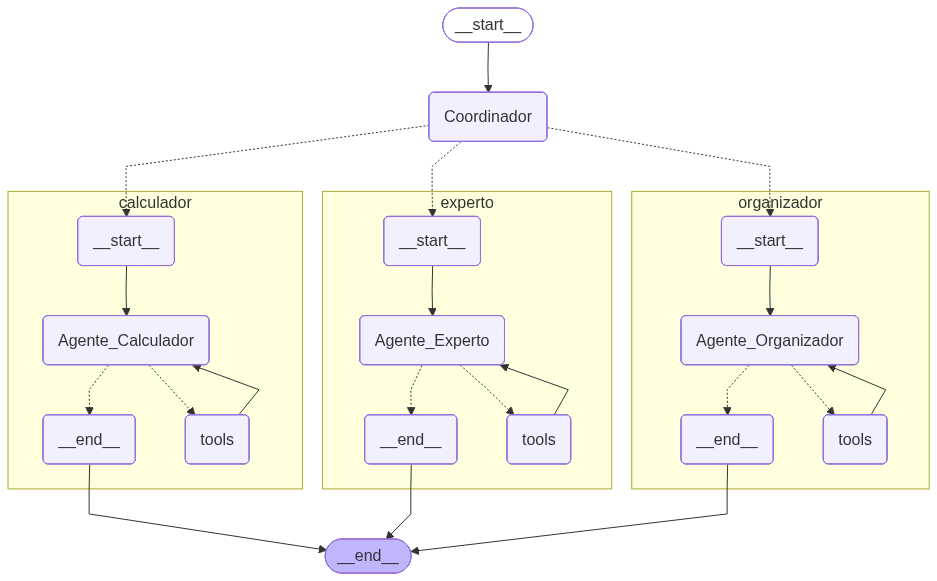

In [55]:
imprimirGrafo(app)

In [56]:
entrada = {"messages": [("user", "Cuanto es la raiz de 64???")]}
for evento in app.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Coordinador': {'siguiente': 'calculador'}}
---
{'calculador': {'messages': [HumanMessage(content='Cuanto es la raiz de 64???', additional_kwargs={}, response_metadata={}, id='c0d1a68b-0b23-4ad3-880b-72e6c9b5eae1'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-16T04:33:47.277881641Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11706978383, 'load_duration': 279367805, 'prompt_eval_count': 376, 'prompt_eval_duration': 24186000, 'eval_count': 393, 'eval_duration': 11313449000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019eceb4-cb51-7e63-aaca-6bf52b94c6c5-0', tool_calls=[{'name': 'evaluar', 'args': {'expresion': '64**0.5'}, 'id': 'ba74f1a3-513d-48a3-b708-a3927e49b45d', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 376, 'output_tokens': 393, 'total_tokens': 769}), ToolMessage(content='8.0', name='evaluar', id='b7227231-9957-478b-88df-7c2d14dde

In [60]:
class Evaluacion(BaseModel):
    valida: bool
    feedback: str

def revisar(state):
    if state["valida"]:        return END           # aprobada
    if state["intentos"] >= 5: return END           # se rinde (evita loop infinito)
    return "Coordinador"                            # reintenta

In [70]:
from langchain_core.messages import HumanMessage
prompt_juez ="""
 Eres un juez, tu mision es ver si el mensaje del usuario fue respondido correctamente por los agentes
 hay cuatro agentes: calculador, organizador, experto y coordinador.

 coordinador: se encarga de elegir el agente correcto para responder el mensaje del usuario.

 calculador: se encarga de resolver problemas matematicos
  por ejemplo:
    ¨Cuanto es dos mas dos?¨
    ¨Cual es la raiz cuadrada de 25?¨
    ¨Cuanto es (2+2) dividido tres?.
 organizador: se encarga de organizar eventos del usuario en un calendario
  por ejemplo:
    ¨Agrega una reunión de estudio de Física el 10 de junio de 2026 a las 15:00 horas.¨
    ¨Modifica mi evento ‘Clase de Historia del 20 de junio de 2026 para que comience a las 10:00.¨
 experto: se encarga de responder preguntas conceptuales del usuario
  por ejemplo:
    ¨Cuales son las fases de la luna?¨
    ¨Cual es la capital de chile?¨

IMPORTANTE: Debes revisar si coordinador eligio correctamente y si calculador, organizador, experto usaron
sus herramientas correctamente.
Si algo falla, valida=False y explica por qué en feedback
 """
def agente_juez(state):
    llm = llama.with_structured_output(Evaluacion)
    system_prompt = [SystemMessage(content=prompt_juez)]
    respuesta = llm.invoke(system_prompt + state["messages"])

    update = {
        "valida": respuesta.valida,
        "feedback": respuesta.feedback,
        "intentos": state["intentos"] + 1,
    }
    if not respuesta.valida:
        update["messages"] = [HumanMessage(content=f"Revisión del juez: {respuesta.feedback}. Corrige la respuesta.")]
    return update

In [71]:
#FLUJO OFICIAL CON JUEZ

totalworkflow = StateGraph(State)
totalworkflow.add_node("Coordinador",agente_coordinador)
totalworkflow.add_node("calculador", app_agenteCalculador)
totalworkflow.add_node("organizador", app_agenteOrganizador)
totalworkflow.add_node("experto", app_agenteExperto)
totalworkflow.add_node("critico", agente_juez)

totalworkflow.add_edge(START, "Coordinador")
totalworkflow.add_conditional_edges("Coordinador", enrutar, {
    "calculador": "calculador",
    "organizador": "organizador",
    "experto": "experto",
})
totalworkflow.add_edge("calculador", "critico")
totalworkflow.add_edge("organizador", "critico")
totalworkflow.add_edge("experto", "critico")

totalworkflow.add_conditional_edges("critico", revisar, {
    "Coordinador": "Coordinador",   # reintenta
    END: END,                        # termina
})

appfinish = totalworkflow.compile()


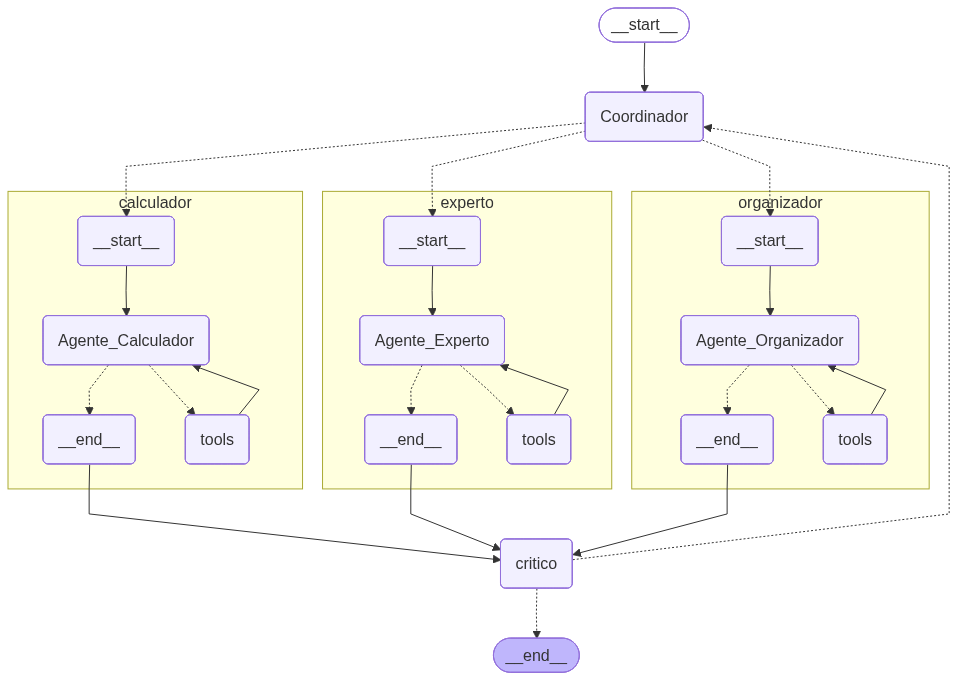

In [62]:
imprimirGrafo(appfinish)

In [72]:
entrada = {"messages": [("user", "Cuanto es la raiz de 64???")],
    "siguiente": "",
    "valida": False,
    "feedback": "",
    "intentos": 0,}
for evento in appfinish.stream(entrada, stream_mode="updates"):
    print(evento)
    print("---")

{'Coordinador': {'siguiente': 'calculador'}}
---
{'calculador': {'messages': [HumanMessage(content='Cuanto es la raiz de 64???', additional_kwargs={}, response_metadata={}, id='4f4328ea-b7e0-445b-88d2-5895bc561e28'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-16T05:07:48.449667254Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11317230187, 'load_duration': 281662046, 'prompt_eval_count': 376, 'prompt_eval_duration': 24472000, 'eval_count': 393, 'eval_duration': 10918814000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019eced3-f22b-7e71-a797-485f981ba6d4-0', tool_calls=[{'name': 'evaluar', 'args': {'expresion': '64**0.5'}, 'id': '15930327-80b5-49f3-ab44-e002f060b0c9', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 376, 'output_tokens': 393, 'total_tokens': 769}), ToolMessage(content='8.0', name='evaluar', id='a8f8934f-614c-4393-8870-d7d0755af